
## 1. Clasificación (algoritmo alterno) — `breast-cancer.csv`
### Algoritmo: Regresión Logística (`LogisticRegression`)

**Justificación del algoritmo:** Se eligió **Regresión Logística** y en el notebook de práctica *Randomized Search-Regresión logística*.
- El algoritmo de Regresión Logística se utiliza a menudo en los problemas de
  clasificación binaria, es más adecuado para situaciones en las que es necesario predecir las
  probabilidades de que la variable dependiente caiga en una de las dos categorías de la respuesta, lo cual
  encaja exactamente con el problema (tumor Maligno vs. Benigno).
- A diferencia del árbol de decisión (modelo de reglas), es un modelo lineal probabilístico que entrega la
  probabilidad de que un tumor sea maligno, útil para establecer umbrales de decisión clínicos.
- Al depender de la escala de las variables, permite ilustrar la importancia del escalamiento de datos
  (mencionada en clase para K-Means) en un algoritmo distinto, algo que no era relevante en el árbol de
  decisión.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay)
from scipy.stats import loguniform

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga y preparación de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'breast-cancer.csv'))
datos = datos.drop(columns=['id'])

le = LabelEncoder()
datos['diagnosis_cod'] = le.fit_transform(datos['diagnosis'])  # B=0, M=1

X = datos.drop(columns=['diagnosis', 'diagnosis_cod']).values
y = datos['diagnosis_cod'].values
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(X.shape, y.shape)


{'B': np.int64(0), 'M': np.int64(1)}
(569, 30) (569,)


### Paso 2. División de datos y escalamiento

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)


### Paso 3. Entrenamiento del modelo base

In [4]:
modelo = LogisticRegression(max_iter=5000, random_state=1)
modelo.fit(X_train_esc, y_train)

predicciones = modelo.predict(X_test_esc)
print('Exactitud:', accuracy_score(y_test, predicciones))


Exactitud: 0.9824561403508771


### Paso 4. Evaluación del modelo base

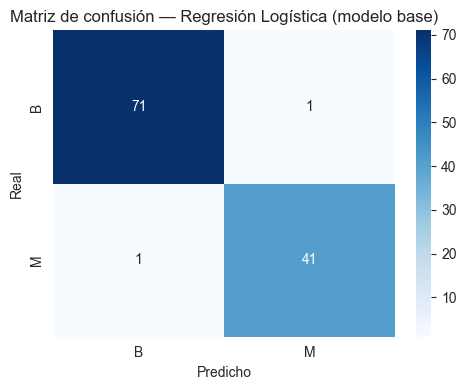

              precision    recall  f1-score   support

           B       0.99      0.99      0.99        72
           M       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


In [5]:
cm = confusion_matrix(y_test, predicciones)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — Regresión Logística (modelo base)')
plt.tight_layout()
plt.savefig('grafica_matriz_confusion_logreg_base.png', dpi=120)
plt.show()

print(classification_report(y_test, predicciones, target_names=['B', 'M']))


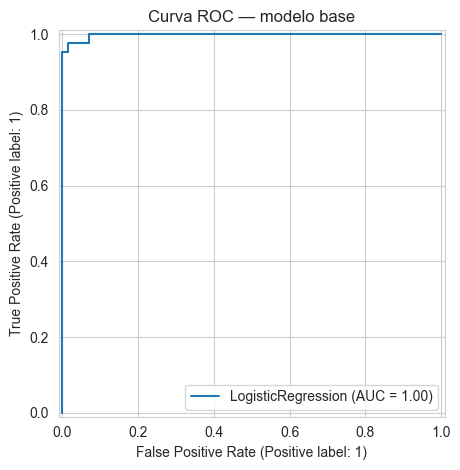

AUC: 0.998015873015873


In [6]:
RocCurveDisplay.from_estimator(modelo, X_test_esc, y_test)
plt.title('Curva ROC — modelo base')
plt.tight_layout()
plt.savefig('grafica_roc_logreg_base.png', dpi=120)
plt.show()
print('AUC:', roc_auc_score(y_test, modelo.predict_proba(X_test_esc)[:, 1]))


### Paso 5. Optimización del modelo — búsqueda de hiperparámetros (RandomizedSearchCV)
Siguiendo la presentación de clase *"Análisis supervisado"* (diapositivas 37-39), que detalla los
hiperparámetros de `LogisticRegression` disponibles en `Sklearn` (`fit_intercept`, `penalty`, `tol`, `C`,
`class_weight`, `solver`, `warm_start`), se construye el siguiente espacio de búsqueda utilizando esos mismos
hiperparámetros:

In [7]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Espacio de búsqueda con los hiperparámetros de Regresión Logística vistos en clase
space = dict()
space['solver'] = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
space['penalty'] = ['l2']
space['C'] = loguniform(1e-3, 100)
space['fit_intercept'] = [True, False]
space['tol'] = loguniform(1e-5, 1e-1)
space['class_weight'] = [None, 'balanced']
space['warm_start'] = [True, False]

search = RandomizedSearchCV(LogisticRegression(max_iter=5000, random_state=1), space, n_iter=60,
                             scoring='accuracy', n_jobs=-1, cv=cv, random_state=1)
result = search.fit(X_train_esc, y_train)

print('Mejor puntuación (CV):', result.best_score_)
print('Mejores hiperparámetros:', result.best_params_)


Mejor puntuación (CV): 0.9809017713365541
Mejores hiperparámetros: {'C': np.float64(10.852404632723829), 'class_weight': None, 'fit_intercept': False, 'penalty': 'l2', 'solver': 'newton-cg', 'tol': np.float64(0.010174003415210846), 'warm_start': False}


C:\Users\Yosue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Paso 6. Reentrenamiento con los mejores hiperparámetros y evaluación final

In [8]:
modelo_opt = LogisticRegression(max_iter=5000, random_state=1, **result.best_params_)
modelo_opt.fit(X_train_esc, y_train)
predicciones_opt = modelo_opt.predict(X_test_esc)

print('Exactitud modelo optimizado:', accuracy_score(y_test, predicciones_opt))
print('Precisión:', precision_score(y_test, predicciones_opt))
print('Recall:', recall_score(y_test, predicciones_opt))
print('F1-score:', f1_score(y_test, predicciones_opt))
print('AUC:', roc_auc_score(y_test, modelo_opt.predict_proba(X_test_esc)[:, 1]))


Exactitud modelo optimizado: 0.9824561403508771
Precisión: 0.9761904761904762
Recall: 0.9761904761904762
F1-score: 0.9761904761904762
AUC: 0.9973544973544974


C:\Users\Yosue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


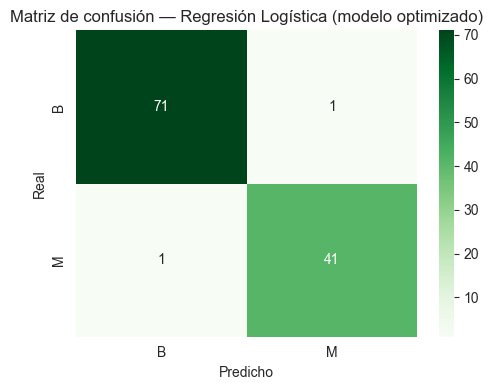

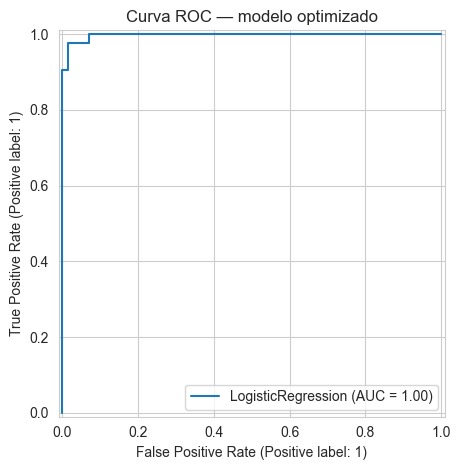

In [9]:
cm_opt = confusion_matrix(y_test, predicciones_opt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — Regresión Logística (modelo optimizado)')
plt.tight_layout()
plt.savefig('grafica_matriz_confusion_logreg_optimizado.png', dpi=120)
plt.show()

RocCurveDisplay.from_estimator(modelo_opt, X_test_esc, y_test)
plt.title('Curva ROC — modelo optimizado')
plt.tight_layout()
plt.savefig('grafica_roc_logreg_optimizado.png', dpi=120)
plt.show()


## Conclusión / Interpretación final
La Regresión Logística optimizada logra un desempeño competitivo frente al árbol de decisión de la sección
SA, con la ventaja de entregar probabilidades calibradas (curva ROC / AUC). La búsqueda de hiperparámetros
ajustó el parámetro de regularización `C` y el algoritmo de optimización (`solver`), mejorando la
generalización del modelo.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
